# Opis

Notatnik służący do wizualizacji przestrzeni ukrytej autoenkoderów

In [6]:
IS_NEW_APPROACH = True
IS_VGAE = True

# Importy

In [10]:
%load_ext autoreload
%autoreload 2
import json
import matplotlib.pyplot as plt

import sys


sys.path.append('../')
import torch
from utils.FramsticksGraphDataset import FramsticksGraphDataset
from pyprojroot import here
from src.models.KlejdaGAE.KlejdaGraphAutoencoder import KlejdaGraphAutoencoder
from src.models.KlejdaGAE.KlejdaVariationalGraphAutoencoder import KlejdaVariationalGraphAutoencoder
from src.models.NewGAE.GraphAutoencoder import GraphAutoencoder
from src.models.NewGAE.VariationalGraphAutoencoder import VariationalGraphAutoencoder
import yaml
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

import plotly.express as px
import pandas as pd
import os

current_dir = os.getcwd()
framspy_path = os.path.abspath(os.path.join(current_dir, '..', 'external', 'framspy'))
if framspy_path not in sys.path:
	sys.path.insert(0, framspy_path)
with open("../configs/final_evolution_config.yaml", 'r') as f:
	evolution_config = yaml.safe_load(f)
import frams

frams.init(
    evolution_config['frams_path']
)

genotypes = []
with open("../results/sampled_best_individuals_merged.jsonl", "r", encoding="utf-8") as f:
	for line in f:
		obj = json.loads(line.strip())
		genotypes.append(obj)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using Framsticks version: 5.5
Home (writable) dir     : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data
Resources dir           : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data



# Przygotowanie autoenkodera

In [11]:
project_dir = here()
# Przygotowanie checkpointów nauczonych autoenkoderów
checkpoints_dir = project_dir / 'notebooks' / 'checkpoints' / 'final_checkpoints'

if IS_NEW_APPROACH:
	checkpoints_dir = checkpoints_dir / 'new'
else:
	checkpoints_dir = checkpoints_dir / 'klejda'
checkpoint_gae = torch.load(checkpoints_dir / 'gae.ckpt')
checkpoint_vgae = torch.load(checkpoints_dir / 'vgae.ckpt')
# Przygotowanie konfiguracji dla gae
configs_dir = project_dir / 'configs'


if IS_NEW_APPROACH:
	config_gae_path = configs_dir / 'gae_config.yaml'
	config_vgae_path = configs_dir / 'gae_config.yaml'
else:
	config_gae_path = configs_dir / 'klejda_gae_config.yaml'
	config_vgae_path = configs_dir / 'klejda_gae_config.yaml'

with open(config_gae_path) as f:
	config_gae = yaml.safe_load(f)
with open(config_vgae_path) as f:
	config_vgae = yaml.safe_load(f)
torch.set_printoptions(precision=10)

In [12]:
# Przygotowanie macierzy wektorów ukrytych
# dataset = FramsticksDummyDataset(num_samples=1000)
NUMBER_OF_EXAMPLES = 3000
# genotypes = []
# with open("../results/sampled_individuals_better.jsonl", "r", encoding="utf-8") as f:
# 	for line in f:
# 		obj = json.loads(line.strip())
# 		genotypes.append(obj)

dataset = FramsticksGraphDataset(genotypes, config_gae["max_nodes"])
dataset_size = len(dataset)

dataloader = DataLoader(
	dataset,
	batch_size=1,
	shuffle=True,
	num_workers=2,
	persistent_workers=True
)

if IS_VGAE:
	if IS_NEW_APPROACH:
		autoencoder = VariationalGraphAutoencoder(config=config_vgae, frams_module=frams)
	else:
		autoencoder = KlejdaVariationalGraphAutoencoder(config=config_vgae, frams_module=frams)
	autoencoder.load_state_dict(checkpoint_vgae['state_dict'])
else:
	if IS_NEW_APPROACH:
		autoencoder = GraphAutoencoder(config=config_gae, frams_module=frams)
	else:
		autoencoder = KlejdaGraphAutoencoder(config=config_gae, frams_module=frams)
	autoencoder.load_state_dict(checkpoint_gae['state_dict'])

autoencoder.eval()

latent_vectors = []
labels = []

# Wyłączenie obliczania gradientów
with torch.no_grad():
	for i, batch in enumerate(dataloader):
		if i >= NUMBER_OF_EXAMPLES:
			break

		# Rozpakowanie batcha
		x_matrix = batch[0]
		a_matrix = batch[1]
		label = batch[2][config_gae['locality_loss_type']].squeeze(0).tolist()
		if config_gae['locality_loss_type'] == 'fitness':
			label = label[0]
		labels.append(label)

		device = next(autoencoder.parameters()).device
		x_matrix = x_matrix.to(device)
		a_matrix = a_matrix.to(device)

		z = autoencoder.encode(x_matrix, a_matrix)

		# Spakowanie do batcha
		z_single = z.squeeze(0).cpu()

		latent_vectors.append(z_single)
latent_vectors = np.array(latent_vectors)
print(f"Pomyślnie wygenerowano {len(latent_vectors)} wektorów ukrytych.")
# Przykładowy podgląd kształtu pierwszego wektora
print(f"Kształt pojedynczego wektora z: {latent_vectors[0].shape}")
# print(f"Labels: {labels}")

RuntimeError: Error(s) in loading state_dict for VariationalGraphAutoencoder:
	size mismatch for encoder_backbone.mlp.weight: copying a param with shape torch.Size([32, 5]) from checkpoint, the shape in current model is torch.Size([32, 3]).
	size mismatch for decoder_x.final_projection.weight: copying a param with shape torch.Size([75, 128]) from checkpoint, the shape in current model is torch.Size([45, 128]).
	size mismatch for decoder_x.final_projection.bias: copying a param with shape torch.Size([75]) from checkpoint, the shape in current model is torch.Size([45]).

# Wizualizacja przestrzeni ukrytej

## PCA 2D

Generowanie wizualizacji PCA dla fitnessu...


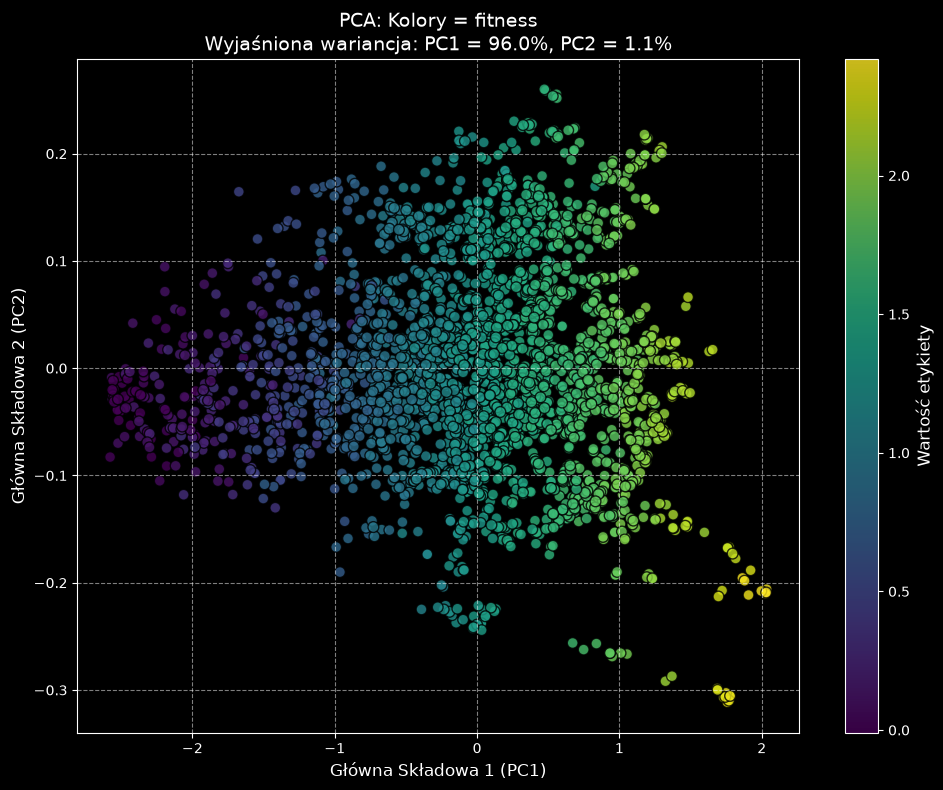

In [18]:
def visualize_pca_2d(latent_vectors, labels, title="Wizualizacja PCA przestrzeni ukrytej (2D)"):
    # 1. Konwersja listy tensorów PyTorch na jedną, płaską macierz Numpy
    if isinstance(latent_vectors[0], torch.Tensor):
        z_matrix = torch.stack(latent_vectors).detach().cpu().numpy()
    else:
        z_matrix = np.array(latent_vectors)

    labels = np.array(labels)

    assert len(z_matrix) == len(labels), "Liczba wektorów i etykiet musi być identyczna!"

    pca = PCA(n_components=2)
    z_pca = pca.fit_transform(z_matrix)

    explained_variance = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(10, 8))

    # Wykres punktowy
    scatter = plt.scatter(
        z_pca[:, 0],
        z_pca[:, 1],
        c=labels,
        cmap='viridis',
        marker='o',
        edgecolors='black',
        alpha=0.8,
        s=60
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label('Wartość etykiety', fontsize=12)

    # for i, label in enumerate(labels):
    #     formatted_label = f"{label:.2f}" if isinstance(label, float) else str(label)
	#
    #     plt.annotate(
    #         formatted_label,
    #         (z_pca[i, 0], z_pca[i, 1]),
    #         textcoords="offset points",
    #         xytext=(5, 4),
    #         ha='left',
    #         fontsize=8,
    #         alpha=0.95
    #     )

    plt.title(f'{title}\nWyjaśniona wariancja: PC1 = {explained_variance[0]:.1f}%, PC2 = {explained_variance[1]:.1f}%', fontsize=14)
    plt.xlabel(f'Główna Składowa 1 (PC1)', fontsize=12)
    plt.ylabel(f'Główna Składowa 2 (PC2)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

print("Generowanie wizualizacji PCA dla fitnessu...")
visualize_pca_2d(latent_vectors, labels, title=f"PCA: Kolory = {config_gae['locality_loss_type']}")


## PCA 3D

In [19]:
def visualize_pca_3d_interactive(latent_vectors, labels, title="Interaktywne PCA 3D"):
    if isinstance(latent_vectors[0], torch.Tensor):
        z_matrix = torch.stack(latent_vectors).detach().cpu().numpy()
    else:
        z_matrix = np.array(latent_vectors)

    labels = np.array(labels)
    assert len(z_matrix) == len(labels), "Liczba wektorów i etykiet musi być identyczna!"

    pca = PCA(n_components=3)
    z_pca = pca.fit_transform(z_matrix)
    exp_var = pca.explained_variance_ratio_ * 100

    hover_texts = [f"Wartość: {lbl:.3f}" if isinstance(lbl, float) else f"Wartość: {lbl}" for lbl in labels]

    df = pd.DataFrame({
        'PC1': z_pca[:, 0],
        'PC2': z_pca[:, 1],
        'PC3': z_pca[:, 2],
        'Etykieta': labels,
        'Szczegóły': hover_texts
    })

    fig = px.scatter_3d(
        df,
        x='PC1',
        y='PC2',
        z='PC3',
        color='Etykieta',          # Kolorowanie na podstawie przekazanych etykiet (np. fitness)
        hover_name='Szczegóły',    # Tekst pojawiający się po najechaniu myszką
        title=f'{title} (Zachowana wariancja: {sum(exp_var):.1f}%)',
        labels={
            'PC1': f'PC1 ({exp_var[0]:.1f}%)',
            'PC2': f'PC2 ({exp_var[1]:.1f}%)',
            'PC3': f'PC3 ({exp_var[2]:.1f}%)'
        },
        color_continuous_scale='Viridis', # Ładna i czytelna mapa kolorów
        opacity=0.85
    )

    fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

    fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

    fig.show()

visualize_pca_3d_interactive(latent_vectors, labels, title="PCA 3D: Kolory = Fitness")

# Wizualizacja ścieżki pętli encode -> decode

In [14]:
def visualize_latent_journey(background_latents: np.ndarray, trajectory_latents: list | np.ndarray):
    if isinstance(background_latents, list):
        background_latents = np.vstack(background_latents)
    if isinstance(trajectory_latents, list):
        trajectory_latents = np.vstack(trajectory_latents)

    # 2. Inicjalizacja i dopasowanie PCA TYLKO na wektorach tła (bazowych)
    pca = PCA(n_components=3)
    pca.fit(background_latents)

    # 3. Transformacja obu zbiorów do tej samej przestrzeni 3D
    bg_pca = pca.transform(background_latents)
    traj_pca = pca.transform(trajectory_latents)

    # 4. Konfiguracja wykresu 3D
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    # 5. Rysowanie tła (przestrzeni wyuczonej) - szare, małe, półprzezroczyste punkty
    ax.scatter(bg_pca[:, 0], bg_pca[:, 1], bg_pca[:, 2],
               c='lightgray', alpha=0.3, s=15, label='Przestrzeń Ukryta (Tło)')

    # 6. Rysowanie wędrówki (ścieżki)
    # Rysujemy linię łączącą punkty
    ax.plot(traj_pca[:, 0], traj_pca[:, 1], traj_pca[:, 2],
            color='red', linewidth=2, linestyle='-', alpha=0.8, label='Ścieżka wędrówki')

    # Rysujemy same punkty (węzły ścieżki)
    ax.scatter(traj_pca[:, 0], traj_pca[:, 1], traj_pca[:, 2],
               c='red', s=50, depthshade=False)

    # 7. Podpisywanie punktów (1, 2, 3...)
    for i in range(len(traj_pca)):
        # Przesunięcie tekstu lekko w górę (Z + mały offset), by nie zlewał się z kropką
        ax.text(traj_pca[i, 0], traj_pca[i, 1], traj_pca[i, 2] + 0.1,
                f'{i+1}', color='black', fontsize=12, fontweight='bold')

    # 8. Kosmetyka wykresu
    ax.set_title('Wędrówka Osobnika w Przestrzeni Ukrytej Z', fontsize=14, pad=20)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')

    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


genotype= "//0\np:-0.154, 0.015, 0.779\np:0.878, 0.617, 0.433, ing=0.336\np:1.451107880326679, 1.4740234394878482, -0.6376058773871252, fr=1.015, ing=0.435\np:1.752, 0.553, -2.387, fr=0.299, ing=0.235\np:-0.07251452161964322, 1.1499264254092, -2.9473799095678204, fr=0.295\np:2.531, 2.278, -2.277\np:0.937, 1.284, -0.217\np:1.292, 1.907, 1.556\nj:0, 1, stif=0.873, rotstif=0.96\nj:2, 1\nj:3, 2, stif=0.855, rotstif=0.919\nj:4, 3\nj:5, 3\nj:6, 1\nj:7, 1\n"

x_matrix, a_matrix , _ = dataset.parse_f0_to_matrices(genotype, 15)
trajectory_latent_vector = []
current_x = x_matrix.unsqueeze(0)
current_a = a_matrix.unsqueeze(0)
steps = 10
autoencoder.eval()
with torch.no_grad():
    for step in range(steps):
        z_current = autoencoder.encode(current_x, current_a)
        trajectory_latent_vector.append(z_current.squeeze(0).cpu().numpy())
        a_probs, x_prime = autoencoder.decode(z_current)
        current_x = x_prime
        current_a = a_probs

visualize_latent_journey(latent_vectors, trajectory_latent_vector)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (15x15 and 3x32)